In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',200)

In [4]:
df = pd.read_csv('Diwali_Sales_Data.csv' ,encoding='latin1' )

# OBJECTIVE: 
#### 1. Improve customer experience by analyzing sales data 
#### 2. Increase revenue 

## Data Cleaning:

In [8]:
df.shape

(11251, 15)

In [9]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [10]:
df.tail()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN
11250,1002744,Brumley,P00281742,F,18-25,19,0,Maharashtra,Western,Healthcare,Office,3,188.0,NaN,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [12]:
df.drop(['Status','unnamed1'], axis=1, inplace=True)

In [14]:
df.isnull().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [15]:
df.dropna(inplace=True)

In [17]:
df.dtypes

User_ID               int64
Cust_name            object
Product_ID           object
Gender               object
Age Group            object
Age                   int64
Marital_Status        int64
State                object
Zone                 object
Occupation           object
Product_Category     object
Orders                int64
Amount              float64
dtype: object

In [18]:
df['Amount'] = df['Amount'].astype('int')

In [21]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [25]:
df.rename(columns ={'Age Group':'Age_Group'}, inplace = True)

In [27]:
df[['Age','Orders','Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


# Exploratory Data Analysis:

In [28]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age_Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

## Gender

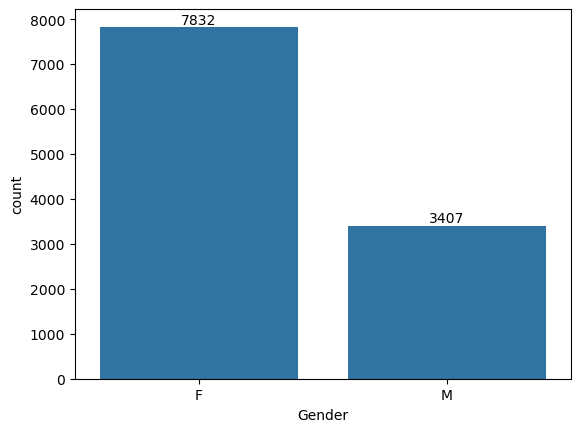

In [53]:
ax = sns.countplot(x = 'Gender' , data = df)
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

In [54]:
sales_gen = df.groupby('Gender',as_index = False)['Amount'].sum().sort_values(by ='Amount', ascending = False)

In [55]:
sales_gen

,Gender,Amount
0,F,74335853
1,M,31913276


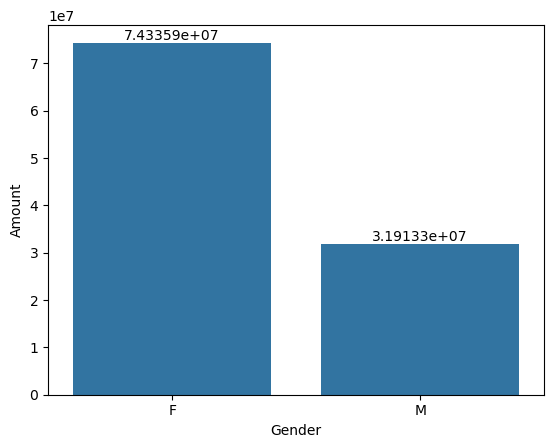

In [56]:
ax = sns.barplot(x='Gender', y='Amount', data =sales_gen)
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

###  Findings: 
### From the above graphs we can see that most of the buyers are females and even the purchasing power of the females are greater than men

In [98]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age_Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

## Age

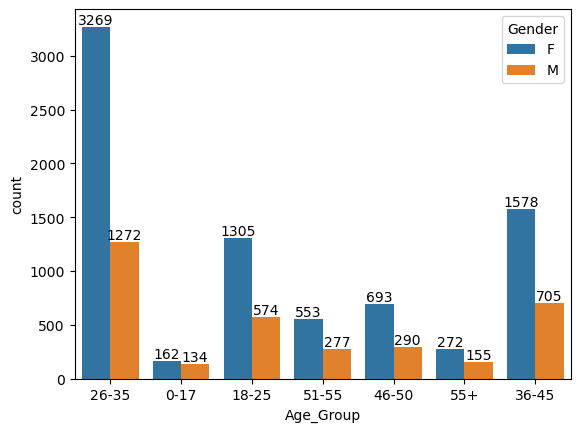

In [99]:
ax = sns.countplot(x= 'Age_Group',data =df, hue ='Gender')
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

In [100]:
sales_age = df.groupby('Age_Group', as_index = False)['Amount'].sum().sort_values(by='Amount',ascending = False)

In [101]:
sales_age

,Age_Group,Amount
2,26-35,42613442
3,36-45,22144994
1,18-25,17240732
4,46-50,9207844
5,51-55,8261477
6,55+,4080987
0,0-17,2699653


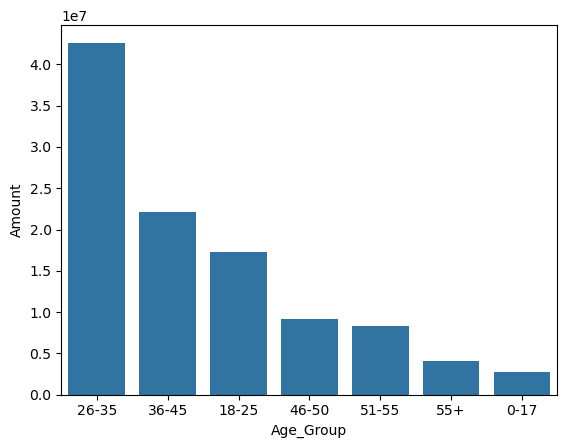

In [102]:
sns.barplot(x='Age_Group', y='Amount', data=sales_age)
plt.show()

###  Findings: 
### From above graphs we can see that most of the buyers are female of age group between 26-35 years 

## State

In [103]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age_Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

### Total number of order from top 10 states

In [104]:
sales_state = df.groupby('State', as_index = False)['Orders'].sum().sort_values(by='Orders' , ascending = False).head(10)

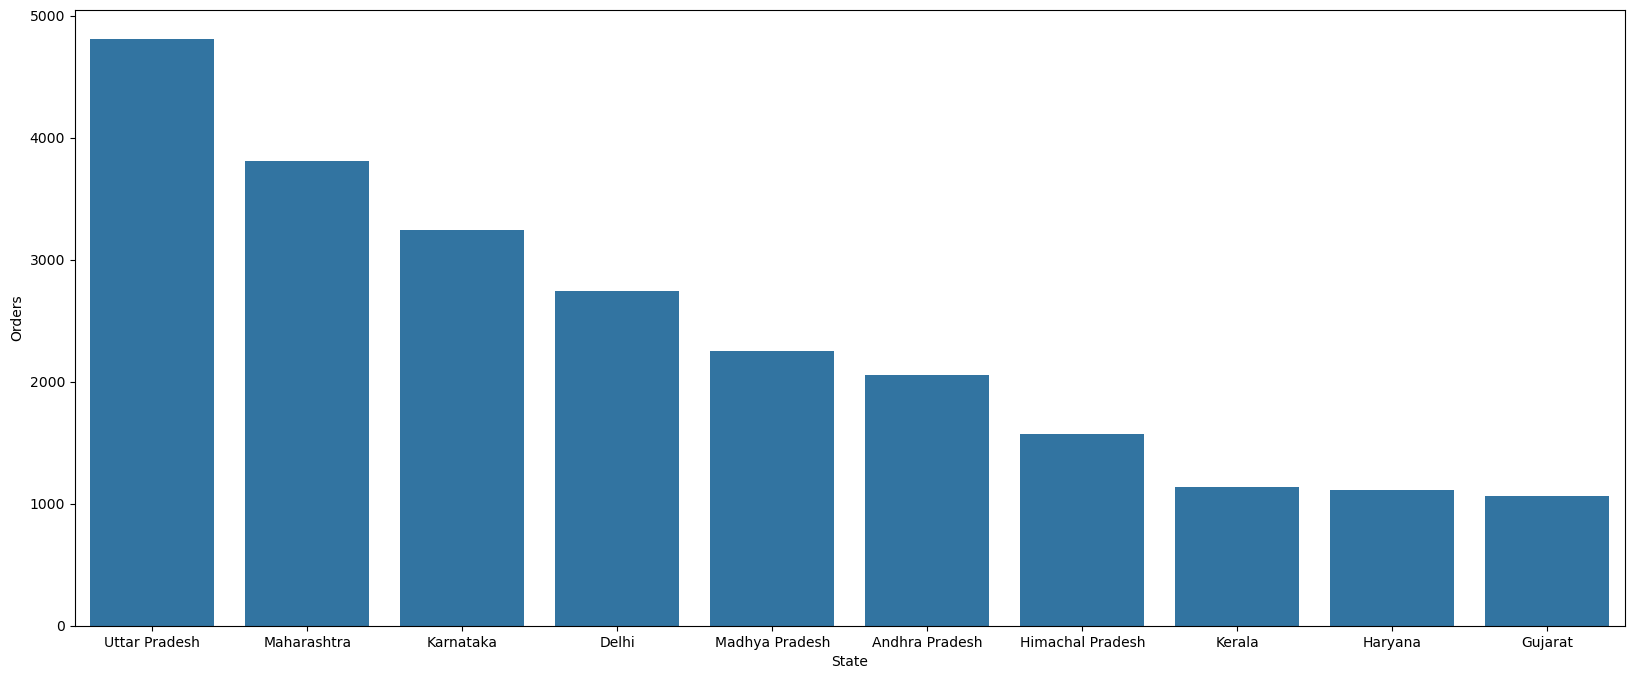

In [105]:
plt.figure(figsize=(20,8))
sns.barplot(x= 'State',y='Orders',data =sales_state)
plt.show()

### Total amount from top 10 states

In [106]:
sales_state = df.groupby('State', as_index = False)['Amount'].sum().sort_values(by='Amount', ascending =False).head(10)

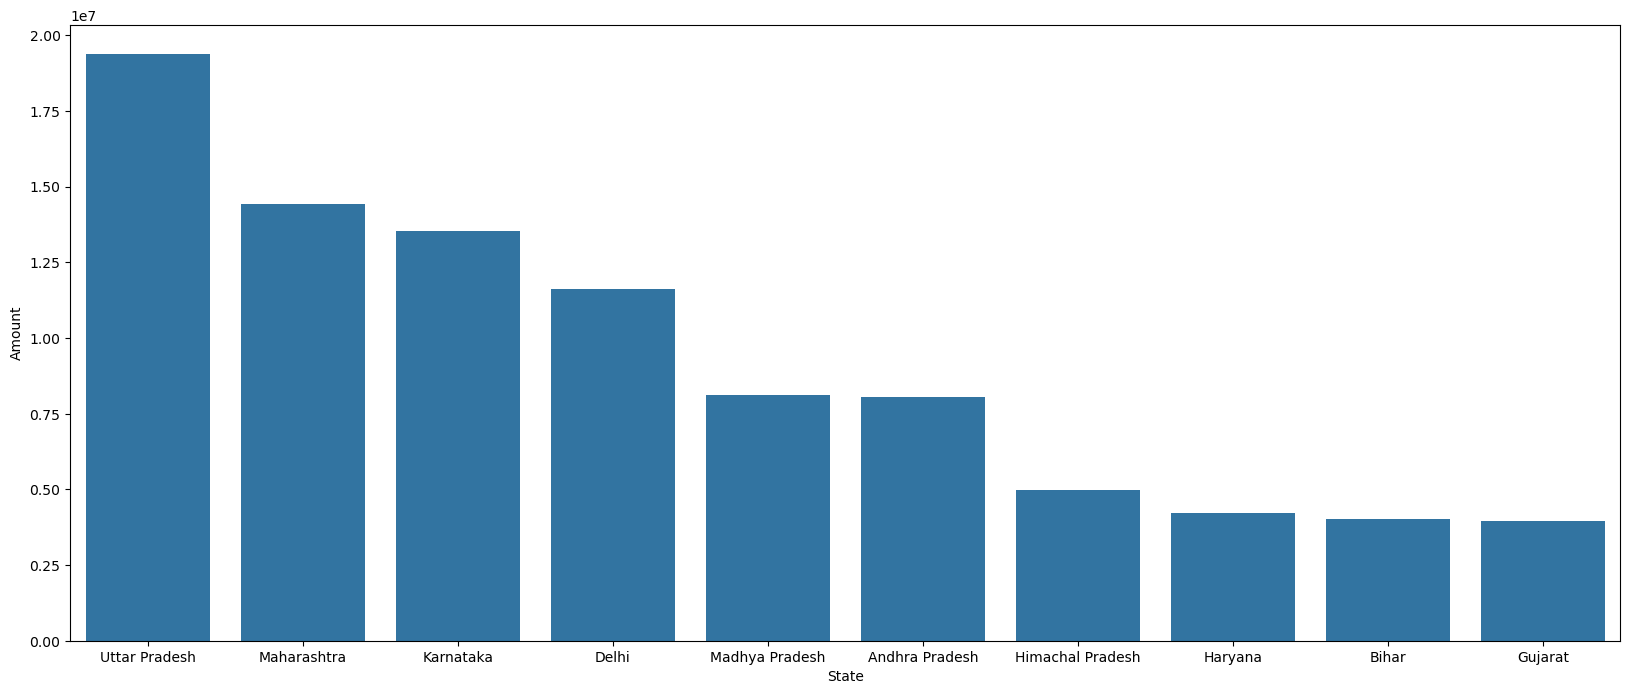

In [107]:
plt.figure(figsize=(20,8))
sns.barplot(x='State',y='Amount',data= sales_state)
plt.show()

###  Findings: 
### From the above graphs we can see that most of the orders are from Uttar Pradesh, Maharashtra and Karnataka. 
### Spending power of Haryana is greater than Kerala.

In [108]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age_Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

## Marital Status

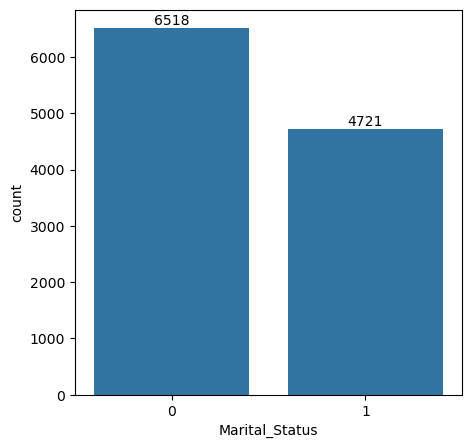

In [109]:
plt.figure(figsize=(5,5))
ax = sns.countplot(x ='Marital_Status',data =df)
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

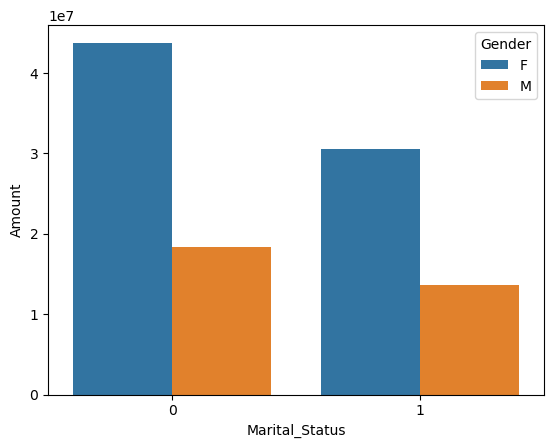

In [110]:
marital_s = df.groupby(['Marital_Status','Gender'],as_index = False)['Amount'].sum().sort_values(by='Amount',ascending =False)
sns.barplot(x='Marital_Status', y ='Amount', hue ='Gender', data=marital_s)
plt.show()

###  Findings: 
###  from the above graphs we can see that most of the buyers are married women and they have higher purchasing power

In [111]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age_Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

## Occupation

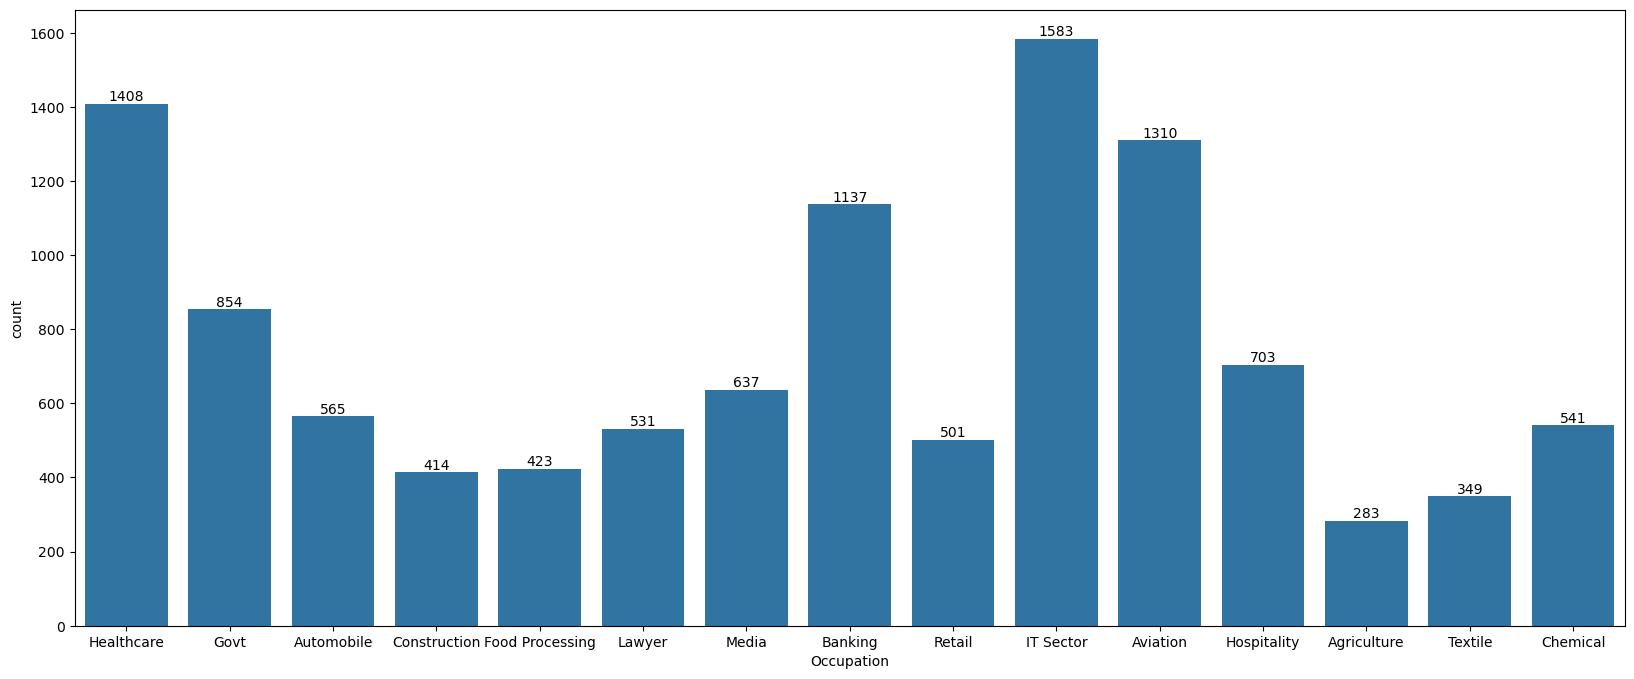

In [112]:
plt.figure(figsize = (20,8))
ax = sns.countplot(x = 'Occupation', data =df)
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

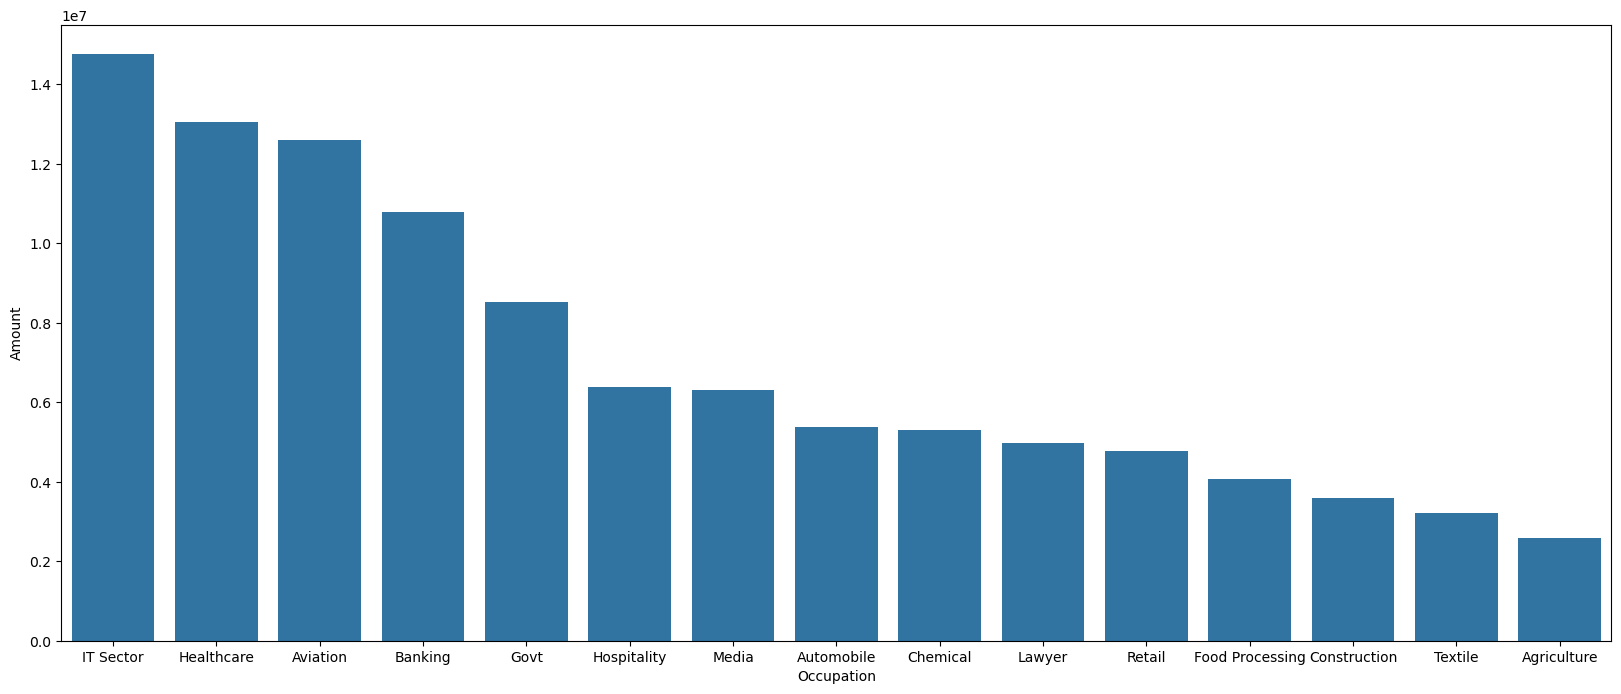

In [113]:
occu_sales = df.groupby('Occupation' , as_index = False)['Amount'].sum().sort_values(by='Amount' ,ascending = False)
plt.figure(figsize = (20,8))
sns.barplot(x = 'Occupation',y='Amount',data = occu_sales)
plt.show()

###  Findings: 
### The purchasing power/ most of the buyers are working in IT, Healthcare and Aviation sector.

In [134]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age_Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

## Product Category

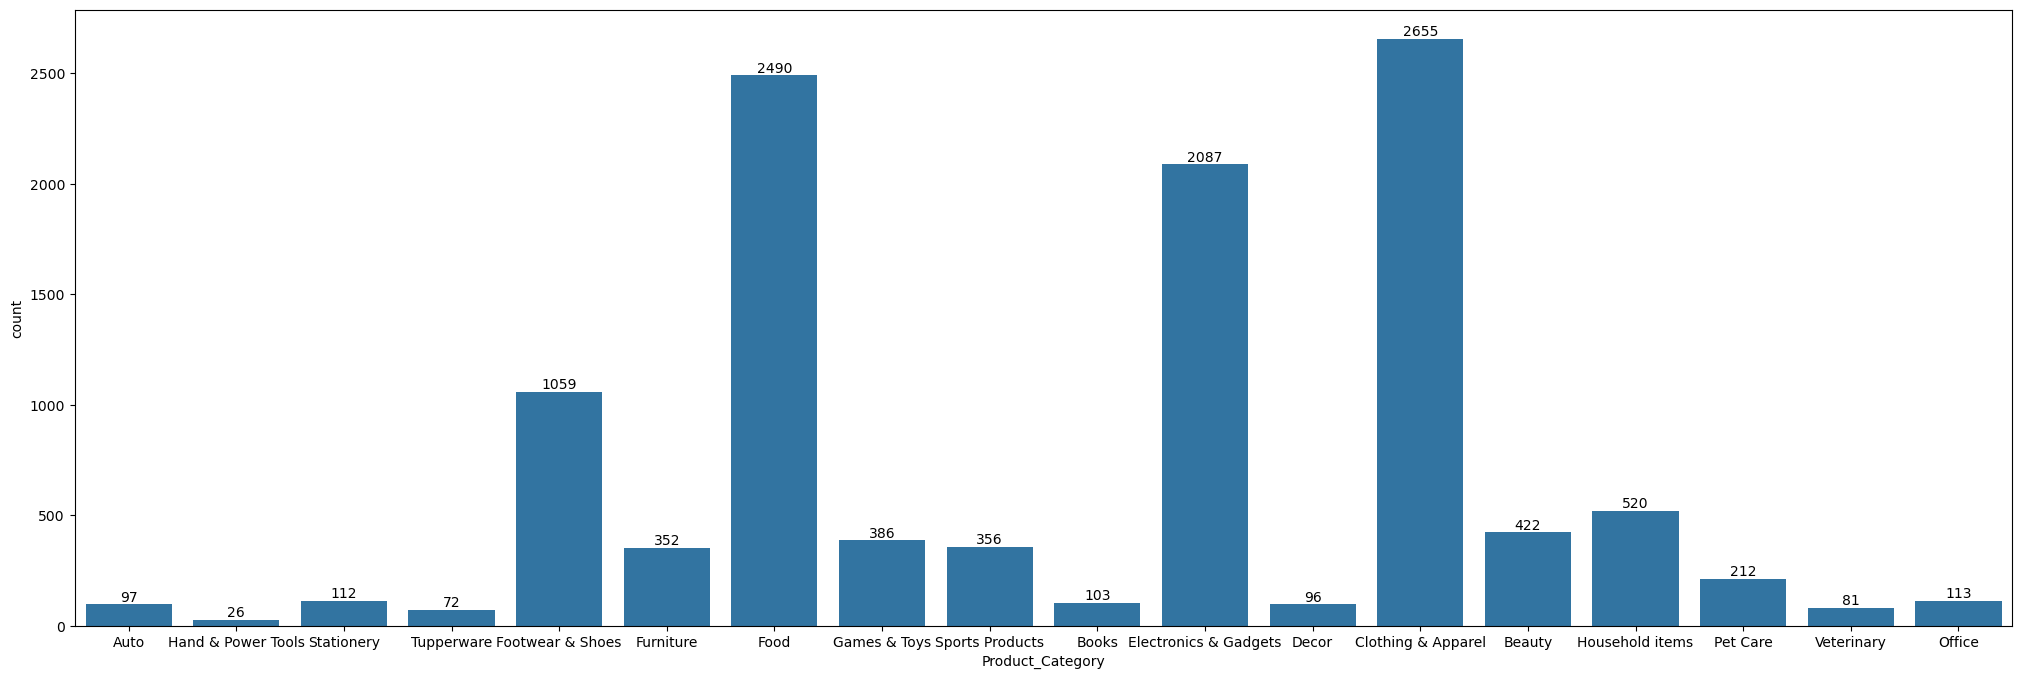

In [135]:
plt.figure(figsize = (25,8))
ax = sns.countplot( x ='Product_Category', data= df)
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

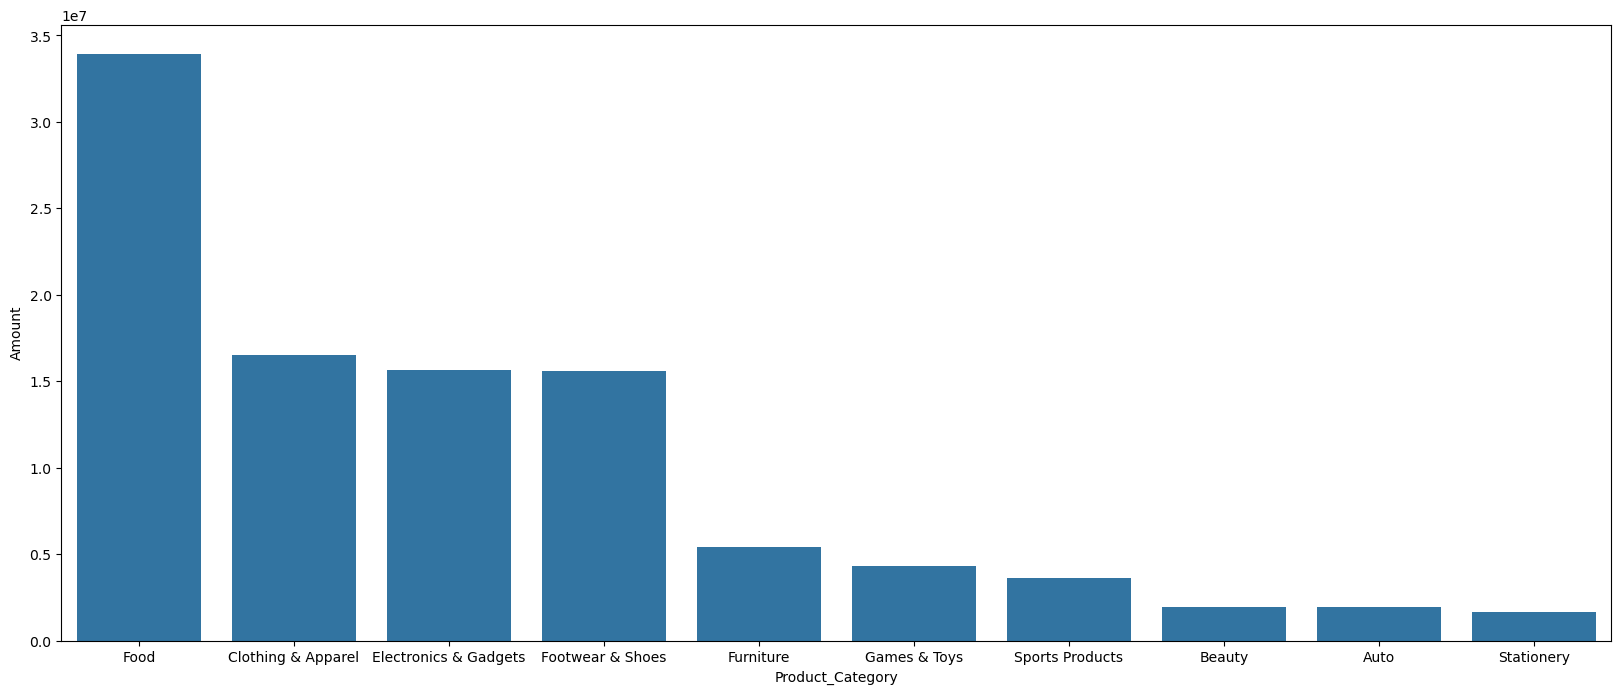

In [136]:
prod_sales = df.groupby('Product_Category',as_index = False)['Amount'].sum().sort_values(by='Amount' , ascending = False).head(10)
plt.figure(figsize = (20,8))
ax = sns.barplot(x = 'Product_Category', y = 'Amount' ,data = prod_sales)
plt.show()

###  Findings: 
###  Most of the products sold are Food, Clothings, Footware and Electronics.
###  Purchasing power Food > Clothing > Electronics 

In [137]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age_Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

## Product ID

### Top selling products 

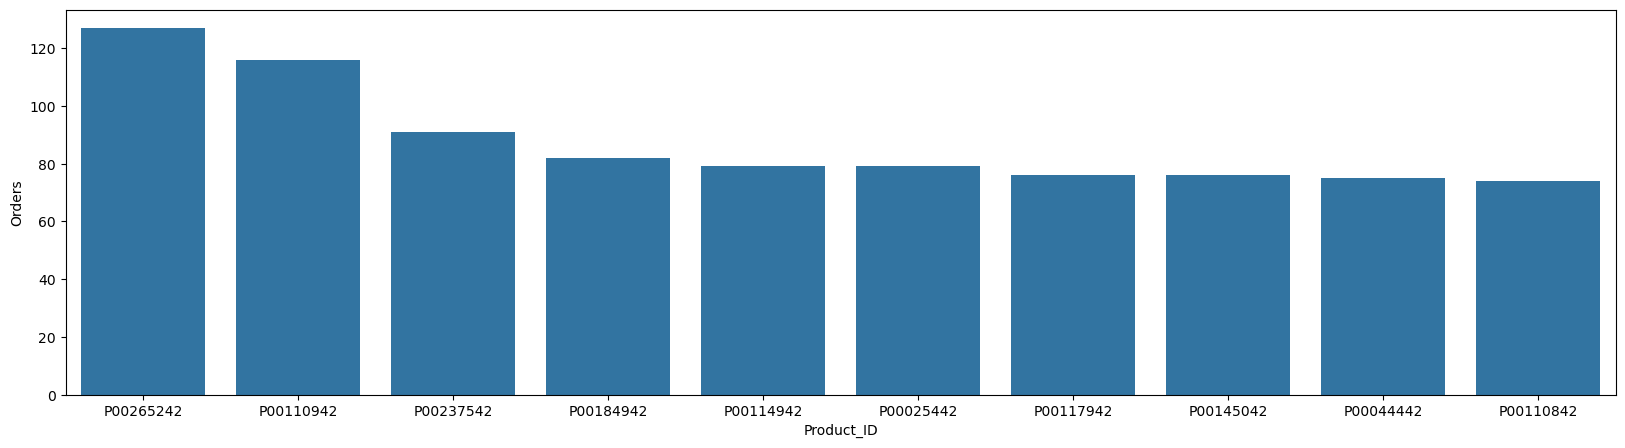

In [142]:
prod_sales = df.groupby('Product_ID' ,as_index = False)['Orders'].sum().sort_values(by='Orders', ascending = False).head(10)
plt.figure(figsize = (20,5))
sns.barplot( x ='Product_ID',y='Orders',data = prod_sales)
plt.show()

# CONCLUSION: 

# Married women age group 26-35 from UP, Maharashtra and Karnataka working in IT, Healthcare and Aviation are more likey to buy products in food, clothing and electronics categories. 

# Improved customer experience by identifying potential customers across different states,
# occupation,gender and age groups.
# Imporved sales by identifying most selling product categories and products
# which can help to plan inventory and hence meet the demands

## **Objective**

* Improve customer experience by identifying key customer segments
* Increase revenue through data-driven targeting and product strategy

---

## **Key Insights**

### **1. Gender-Based Analysis**

* Female customers contribute **~70% of total revenue** (₹74.3M vs ₹31.9M)
* Indicates strong dominance in both purchase volume and revenue contribution

**Insight:**
Female customers are the primary revenue drivers, not just frequent buyers

---

### **2. Age Group Analysis**

* Highest revenue contribution from **26–35 age group (~₹42.6M)**
* Followed by **36–45 and 18–25 segments**

**Insight:**
Young to mid-age working professionals form the core customer base

---

### **3. State-Level Analysis**

* Highest order volume from:

  * Uttar Pradesh
  * Maharashtra
  * Karnataka

* Variation observed in spending patterns across states

**Insight:**
High-volume states drive demand, but revenue contribution should be evaluated alongside average spend for accurate targeting

---

### **4. Marital Status**

* Married women show higher purchasing contribution

**Insight:**
Married female segment represents a high-value and stable customer group

---

### **5. Occupation Analysis**

* Top contributing sectors:

  * IT
  * Healthcare
  * Aviation

**Insight:**
Working professionals in stable, higher-income sectors contribute significantly to revenue

---

### **6. Product Category Analysis**

* Top categories by revenue:

  * Food
  * Clothing
  * Electronics

**Insight:**
Daily-use and lifestyle products dominate sales, indicating practical and recurring purchase behavior

---

## **Business Recommendations**

### **1. Target High-Value Customer Segment**

* Focus on:

  * Females aged 26–35
  * Working in IT, Healthcare, Aviation
  * Located in UP, Maharashtra, Karnataka

**Action:**

* Run targeted digital campaigns (social media, personalized ads)
* Offer segment-specific promotions

---

### **2. Increase Average Order Value**

**Action:**

* Bundle products (e.g., clothing + accessories)
* Cross-sell electronics with add-ons or warranties

---

### **3. Optimize Inventory by Region**

**Action:**

* Increase stock availability in high-demand states
* Improve delivery speed to boost repeat purchases

---

### **4. Segment-Based Pricing Strategy**

**Action:**

* Identify high average spend regions
* Introduce premium product offerings in those markets

---

### **5. Improve Customer Retention**

**Action:**

* Introduce loyalty programs for repeat customers
* Use email/SMS campaigns for personalized offers

---

## **Conclusion**

The analysis identifies **married women aged 26–35 in key states and professional sectors** as the primary revenue-driving segment.

By aligning marketing, inventory, and product strategies toward this group, the business can significantly improve customer experience and drive revenue growth.


## **Objective**

* Improve customer experience by identifying key customer segments
* Increase revenue through data-driven insights

---

## **Key Insights**

### **1. Gender-Based Analysis**

* Female customers contribute **~70% of total revenue** (₹74.3M vs ₹31.9M)
* Indicates significantly higher participation and spending compared to male customers

**Insight:**
Female customers are the primary revenue drivers and should be the focus of targeted marketing strategies

---

### **2. Age Group Analysis**

* Highest revenue contribution from **26–35 age group (~₹42.6M)**
* Followed by **36–45 (~₹22.1M)** and **18–25 (~₹17.2M)**

**Insight:**
Young to mid-age working professionals form the core customer segment

---

### **3. State-Level Analysis**

* Highest order volume from:

  * Uttar Pradesh
  * Maharashtra
  * Karnataka

* Differences observed between order volume and spending patterns across states

**Insight:**
High-demand states drive volume, but revenue optimization requires focusing on both total sales and average spend

---

### **4. Marital Status Analysis**

* Married women contribute the majority of revenue

**Insight:**
Married female customers represent a stable, high-value segment with strong purchasing power

---

### **5. Occupation Analysis**

* Top contributing occupations:

  * IT
  * Healthcare
  * Aviation

**Insight:**
Customers from professional sectors with stable income levels contribute significantly to sales

---

### **6. Product Category Analysis**

* Top revenue-generating categories:

  * Food
  * Clothing
  * Electronics

**Insight:**
Customers prioritize essential and lifestyle products, indicating consistent and repeat purchasing behavior

---

## **Business Recommendations**

### **1. Target High-Value Customer Segment**

Focus on:

* Females aged 26–35
* Working in IT, Healthcare, Aviation
* Located in Uttar Pradesh, Maharashtra, Karnataka

**Action:**

* Run targeted marketing campaigns
* Provide personalized offers and promotions

---

### **2. Increase Average Order Value**

**Action:**

* Introduce product bundling (e.g., clothing + accessories)
* Implement cross-selling strategies across categories

---

### **3. Optimize Inventory and Supply Chain**

**Action:**

* Increase inventory in high-demand states
* Improve delivery efficiency to boost customer satisfaction and repeat purchases

---

### **4. Region-Based Pricing Strategy**

**Action:**

* Identify high-spending regions using average order value
* Introduce premium products in those markets

---

### **5. Improve Customer Retention**

**Action:**

* Implement loyalty programs
* Use targeted communication (email/SMS) for repeat engagement

---

## **Conclusion**

The analysis identifies **married women aged 26–35 in key states and professional sectors** as the primary revenue-driving segment.

By aligning marketing, inventory, and product strategies toward this segment, the business can improve customer experience and drive sustainable revenue growth.
